# Exercício 01: Comparando os otimizadores

A ideia deste exercício é comparar três otimizadores diferentes para minimizar a função não linear de Rosenbrock: *Momentum Gradient Descent*, *Nesterov Accelerated Gradient (NAG)* e *Adam*.

Todas as implementações são feitas do zero em PyTorch, reutilizando apenas operações com tensores e diferenciação automática. Isso permite observar explicitamente o estado interno e a regra de atualização de cada método.

### Protocolo experimental

Todos os métodos partem de $w^{(0)}=(0{,}6, 0{,}4)$ e registram dez pontos: a condição inicial e nove atualizações. As taxas de aprendizado são ajustadas separadamente para evitar divergência; por isso, a comparação é qualitativa e restrita a este problema, ponto inicial e horizonte curto.

**Autor: Lucas Torres Marques**

## Função de Rosenbrock

Vamos começar, portanto, implementando a função de Rosenbrock exatamente como o livro *Machine Learning Methods in Geoscience* fez no capítulo *3.1. AD HOC GRADIENT DESCENT METHODS*, página 51. Tal que:

$$
\epsilon = 100(w_2 − w_1^2)^2 + (1 − w_1)^2
$$

A função `rosenbrock(w)` recebe um vetor de pesos com dois elementos e retorna o erro a ser minimizado. Seu mínimo global é $w^*=(1,1)$, onde $\epsilon(w^*)=0$.

Apesar de possuir apenas duas variáveis, a função é um teste difícil: seu vale é estreito, curvo e apresenta escalas muito diferentes nas direções $w_1$ e $w_2$. Um otimizador pode reduzir rapidamente o erro transversal ao vale e ainda avançar lentamente em direção ao mínimo.

In [39]:
import torch


def rosenbrock(w: torch.Tensor) -> torch.Tensor:
    """Calcula f(w) = 100(w₂ - w₁²)² + (1 - w₁)²."""
    if w.numel() != 2:
        raise ValueError("w deve conter exatamente dois elementos: w1 e w2.")

    w1, w2 = w.reshape(-1)
    return 100.0 * (w2 - w1**2) ** 2 + (1.0 - w1) ** 2


# Ponto inicial de exemplo; requires_grad=True habilita o cálculo dos gradientes.
w = torch.tensor([-1.0, 1.0], dtype=torch.float32, requires_grad=True)
loss = rosenbrock(w)
loss

tensor(4., grad_fn=<AddBackward0>)

Interpretando o resultado acima, a função retorna erro `4` em $w=(-1,1)$. Nesse ponto, o termo $100(w_2-w_1^2)^2$ é zero, pois $w_2=w_1^2$, enquanto $(1-w_1)^2=4$. Portanto, estar sobre o vale parabólico não significa estar no mínimo: ainda é necessário percorrê-lo até $(1,1)$.

## Funções auxiliares

As próximas funções separam o protocolo experimental das regras específicas de cada otimizador. `optimize(...)` executa o ciclo comum de diferenciação e atualização, enquanto `plot_rosenbrock_trajectory(...)` padroniza a visualização. Essa separação reduz duplicação e torna a comparação mais consistente.

In [40]:
def optimize(objective, parameters, optimizer, num_points: int = 10):
    """Executa a otimização e registra os parâmetros e erros a cada passo."""
    if num_points < 2:
        raise ValueError("num_points deve ser pelo menos 2.")

    # Materializa o iterável para reutilizar os mesmos tensores em cada passo.
    parameters = list(parameters)

    def snapshot():
        # detach() registra os valores sem manter todo o grafo de autograd.
        return torch.cat([parameter.detach().reshape(-1) for parameter in parameters])

    # O ponto inicial também faz parte da trajetória e do histórico de erro.
    trajectory = [snapshot()]
    with torch.no_grad():
        loss_history = [objective(*parameters).item()]

    for _ in range(1, num_points):
        # Cada otimizador decide onde o gradiente será avaliado: w ou o look-ahead.
        optimizer.zero_grad()
        loss = objective(*optimizer.gradient_parameters())
        loss.backward()
        optimizer.step()

        # O histórico sempre usa o parâmetro atualizado, e não o ponto antecipado.
        trajectory.append(snapshot())
        with torch.no_grad():
            loss_history.append(objective(*parameters).item())

    return {
        "trajectory": torch.stack(trajectory),
        "loss_history": torch.tensor(loss_history, dtype=parameters[0].dtype),
    }

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm


def plot_rosenbrock_trajectory(
    trajectory,
    optimizer_name: str,
    color: str = "cyan",
    xlim=(0.4, 1.2),
    ylim=(0.2, 1.2),
):
    """Plota uma trajetória sobre as curvas de nível da Rosenbrock."""
    # Constrói a superfície de erro no mesmo domínio usado por todos os métodos.
    w1_values = np.linspace(0, 2, 1_000)
    w2_values = np.linspace(0, 2, 1_000)
    W1, W2 = np.meshgrid(w1_values, w2_values)
    error_surface = 100.0 * (W2 - W1**2) ** 2 + (1.0 - W1) ** 2
    # Níveis logarítmicos revelam simultaneamente o fundo e o vale estreito.
    levels = np.logspace(-2, 3, 30)
    # A conversão explícita permite plotar trajetórias calculadas em CPU ou GPU.
    trajectory_np = trajectory.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(12, 8))
    background = ax.contourf(
        W1, W2, error_surface, levels=levels,
        norm=LogNorm(vmin=levels[0], vmax=levels[-1]),
        cmap="viridis", extend="both",
    )
    ax.contour(
        W1, W2, error_surface, levels=levels,
        norm=LogNorm(vmin=levels[0], vmax=levels[-1]),
        colors="white", linewidths=0.35, alpha=0.45,
    )
    ax.plot(
        trajectory_np[:, 0], trajectory_np[:, 1], marker="o",
        color=color, markeredgecolor="black", linewidth=2,
        label=f"Trajetória do {optimizer_name}",
    )
    ax.scatter(
        *trajectory_np[0], marker="*", color="purple",
        edgecolor="white", s=150, label="Ponto inicial", zorder=5,
    )
    ax.scatter(
        *trajectory_np[-1], color="red", edgecolor="white",
        s=60, label="Ponto final", zorder=5,
    )
    ax.scatter(
        1.0, 1.0, marker="*", color="yellow", edgecolor="black",
        s=180, label="Mínimo (1, 1)", zorder=6,
    )
    fig.colorbar(background, ax=ax, label="Erro da função de Rosenbrock")
    ax.set(
        title=f"Trajetória do {optimizer_name} sobre a função de Rosenbrock",
        xlabel="w1", ylabel="w2", xlim=xlim, ylim=ylim,
    )
    ax.legend(loc="upper right")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()
    return fig, ax


A função acima é reutilizada para todos os otimizadores. A escala logarítmica das curvas de nível é importante porque os valores da Rosenbrock variam por várias ordens de grandeza. O uso dos mesmos limites nos eixos evita que diferenças de enquadramento sejam confundidas com diferenças de desempenho.

## Método do momento

No método do momento, é adicionado/acumulado uma média exponencial dos gradientes:

$$v_t = \beta v_{t-1} + \alpha \nabla \epsilon(w_t)$$

$$w_{t+1} = w_t - v_t$$

A implementação abaixo usa os mesmos parâmetros do código 3.1.1 do livro de referência, em MATLAB: $\alpha=0{,}007$, $\beta=0{,}9$, ponto inicial $(0{,}6, 0{,}4)$ e 10 pontos na trajetória.

In [42]:
class Momentum:
    """Otimizador Momentum implementado apenas com operações de tensores."""

    def __init__(self, parameters, learning_rate: float = 0.007, beta: float = 0.9):
        # Evita learning_rate <= 0 e beta fora do intervalo [0, 1).
        if learning_rate <= 0:
            raise ValueError("learning_rate deve ser positivo.")
        if not 0 <= beta < 1:
            raise ValueError("beta deve pertencer ao intervalo [0, 1).")

        self.parameters = list(parameters)
        self.learning_rate = learning_rate
        self.beta = beta
        # Cada tensor de parâmetros possui uma velocidade acumulada independente.
        self.velocities = [torch.zeros_like(parameter) for parameter in self.parameters]

    def zero_grad(self) -> None:
        # Impede que o autograd acumule gradientes de iterações anteriores.
        for parameter in self.parameters:
            parameter.grad = None

    def gradient_parameters(self):
        """Retorna os pontos nos quais o gradiente deve ser calculado."""
        return self.parameters

    @torch.no_grad()
    def step(self) -> None:
        # A atualização é feita sem construir um novo grafo de diferenciação.
        for parameter, velocity in zip(self.parameters, self.velocities):
            if parameter.grad is None:
                continue

            # v_t = beta * v_(t-1) + alpha * gradiente.
            velocity.mul_(self.beta).add_(parameter.grad, alpha=self.learning_rate)
            # w_(t+1) = w_t - v_t.
            parameter.sub_(velocity)

In [75]:
learning_rate = 7e-3
beta = 0.9
num_points = 10  # Como no MATLAB: ponto inicial + 9 atualizações.

w_momentum = torch.tensor([0.6, 0.4], dtype=torch.float64, requires_grad=True)
momentum_optimizer = Momentum([w_momentum], learning_rate=learning_rate, beta=beta)
momentum_result = optimize(rosenbrock, [w_momentum], momentum_optimizer, num_points)

print(f"Ponto final: ({w_momentum[0].item():.6f}, {w_momentum[1].item():.6f})")
print(f"Erro final: {momentum_result['loss_history'][-1].item():.6f}")
momentum_result["trajectory"]

Ponto final: (0.553804, 0.244304)
Erro final: 0.588399


tensor([[0.6000, 0.4000],
        [0.6728, 0.3440],
        [0.5382, 0.4457],
        [0.6587, 0.3188],
        [0.5596, 0.3657],
        [0.5589, 0.3344],
        [0.5989, 0.2754],
        [0.5009, 0.3389],
        [0.5431, 0.2728],
        [0.5538, 0.2443]], dtype=torch.float64)

### Trajetória sobre as curvas de nível

As cores e as curvas de nível representam o valor da função de Rosenbrock. A escala logarítmica permite visualizar tanto o vale próximo do mínimo quanto as regiões de erro elevado. A trajetória revela não apenas o ponto final, mas também oscilações, mudanças de direção e a capacidade do método de acompanhar a curvatura do vale.

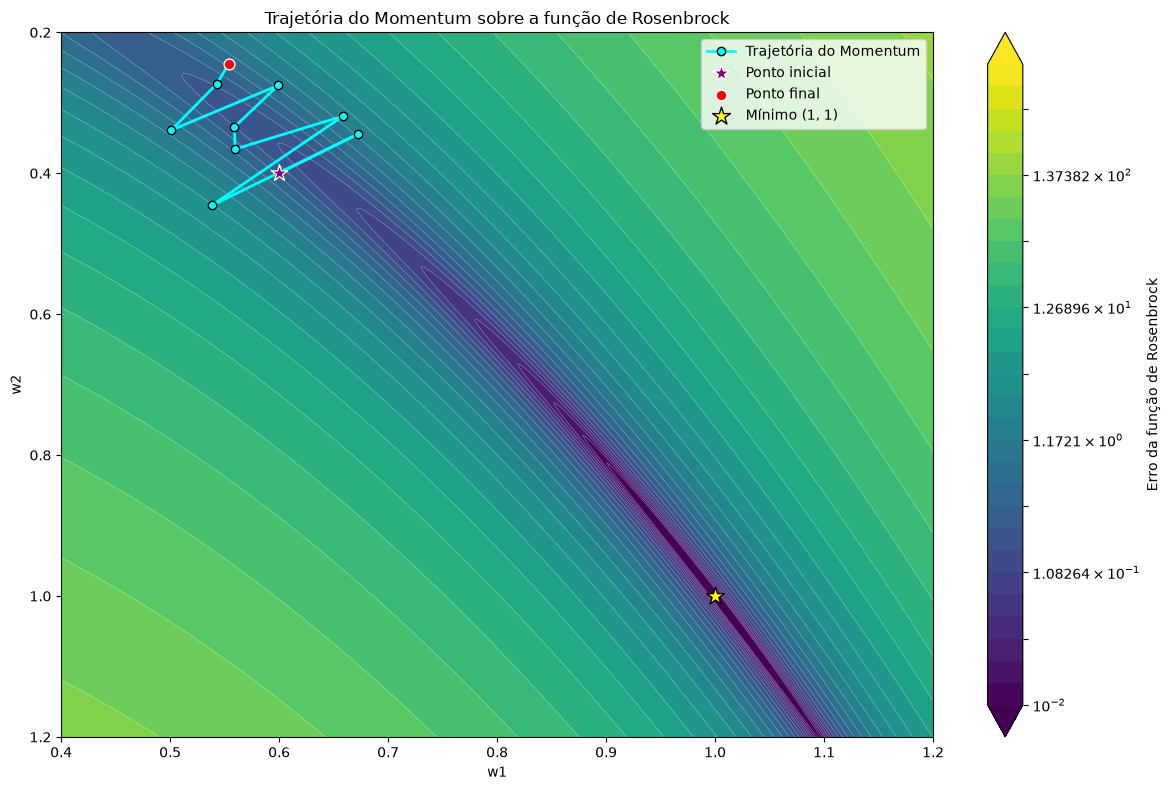

In [76]:
plot_rosenbrock_trajectory(momentum_result["trajectory"], "Momentum")
plt.show()

### Análise do Momentum

O erro parte de `0,320000`, cresce até `2,648768` e termina em `0,588399`. A trajetória alterna entre os dois lados do vale, evidenciando que a velocidade acumulada conserva parte da direção anterior mesmo quando a inclinação local muda. Com apenas nove atualizações e $\alpha=0{,}007$, o método não estabiliza e termina pior que a condição inicial.

Isso não significa que o Momentum seja inadequado em geral. O resultado mostra sua sensibilidade à combinação entre taxa de aprendizado, momento e número de passos. Uma taxa menor, mais iterações ou uma estratégia de decaimento de $\alpha$ poderia amortecer as oscilações.

## Nesterov Accelerated Gradient (NAG)

O NAG calcula o gradiente em uma estimativa antecipada da próxima posição, em vez de usar diretamente o ponto atual:

$$v_t = \beta v_{t-1} + \alpha \nabla \epsilon(w_t - \beta v_{t-1})$$

$$w_{t+1} = w_t - v_t$$

A classe reutiliza a atualização do Momentum e altera somente o ponto no qual o gradiente é calculado. Como o gradiente antecipado torna $\alpha=0{,}007$ instável neste exemplo, usamos $\alpha=0{,}002$ para o NAG e mantemos $\beta=0{,}9$.

In [77]:
class NesterovAcceleratedGradient(Momentum):
    """Momentum com gradiente calculado no ponto antecipado w - beta * v."""

    def gradient_parameters(self):
        # Avalia a inclinação onde o momento atual levaria os parâmetros.
        return [
            parameter - self.beta * velocity
            for parameter, velocity in zip(self.parameters, self.velocities)
        ]

In [78]:
nag_learning_rate = 2e-3
w_nag = torch.tensor([0.6, 0.4], dtype=torch.float64, requires_grad=True)
nag_optimizer = NesterovAcceleratedGradient(
    [w_nag], learning_rate=nag_learning_rate, beta=beta
)
nag_result = optimize(rosenbrock, [w_nag], nag_optimizer, num_points)

print(f"Ponto final: ({w_nag[0].item():.6f}, {w_nag[1].item():.6f})")
print(f"Erro final: {nag_result['loss_history'][-1].item():.6f}")
nag_result["trajectory"]

Ponto final: (0.638078, 0.405384)
Erro final: 0.131297


tensor([[0.6000, 0.4000],
        [0.6208, 0.3840],
        [0.6208, 0.3854],
        [0.6229, 0.3861],
        [0.6245, 0.3882],
        [0.6266, 0.3908],
        [0.6290, 0.3939],
        [0.6318, 0.3974],
        [0.6348, 0.4012],
        [0.6381, 0.4054]], dtype=torch.float64)

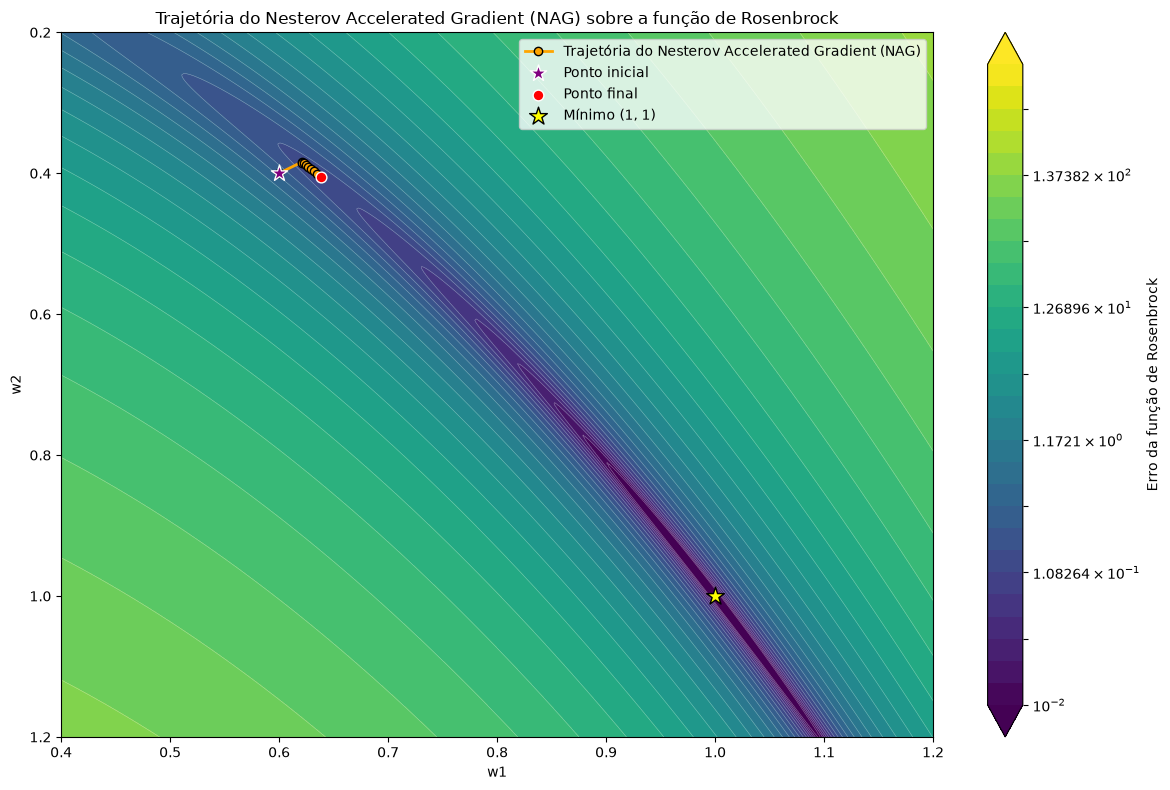

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Trajetória do Nesterov Accelerated Gradient (NAG) sobre a função de Rosenbrock'}, xlabel='w1', ylabel='w2'>)

In [79]:
plot_rosenbrock_trajectory(
    nag_result["trajectory"], "Nesterov Accelerated Gradient (NAG)", color="orange"
)

### Análise do NAG

Com $\alpha=0{,}002$, o erro cai de `0,320000` para `0,143987` já na primeira atualização e depois diminui continuamente até `0,131297`. O gradiente antecipado corrige a direção antes de aplicar toda a velocidade, reduzindo a oscilação transversal observada no Momentum.

A taxa usada aqui é menor porque $\alpha=0{,}007$ tornou o NAG instável neste ponto inicial. Portanto, a melhora observada combina a regra de antecipação com uma escolha mais conservadora de hiperparâmetro.

## Adam Gradient Descent

O Adam combina uma média exponencial dos gradientes (primeiro momento) com uma média exponencial dos quadrados dos gradientes (segundo momento):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$

Como ambos começam em zero, aplicamos as correções de viés $\hat{m}_t=m_t/(1-\beta_1^t)$ e $\hat{v}_t=v_t/(1-\beta_2^t)$. A atualização é:

$$w_{t+1} = w_t - \alpha \left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\eta} + \lambda w_t\right)$$

Usamos $\beta_1=0{,}9$, $\beta_2=0{,}99$, $\eta=10^{-8}$ e $\alpha=0{,}01$. A regularização L2 é opcional e permanece desativada com $\lambda=0$.

In [57]:
class Adam:
    """Otimizador Adam implementado apenas com operações de tensores."""

    def __init__(
        self,
        parameters,
        learning_rate: float = 0.01,
        beta1: float = 0.9,
        beta2: float = 0.99,
        epsilon: float = 1e-8,
        weight_decay: float = 0.0,
    ):
        # Garante que os hiperparâmetros representam médias e passos válidos.
        if learning_rate <= 0:
            raise ValueError("learning_rate deve ser positivo.")
        if not 0 <= beta1 < 1 or not 0 <= beta2 < 1:
            raise ValueError("beta1 e beta2 devem pertencer ao intervalo [0, 1).")
        if epsilon <= 0:
            raise ValueError("epsilon deve ser positivo.")
        if weight_decay < 0:
            raise ValueError("weight_decay não pode ser negativo.")

        self.parameters = list(parameters)
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.weight_decay = weight_decay
        self.time_step = 0

        # m e v começam em zero, causando o viés corrigido durante step().
        self.first_moments = [torch.zeros_like(parameter) for parameter in self.parameters]
        self.second_moments = [torch.zeros_like(parameter) for parameter in self.parameters]

    def zero_grad(self) -> None:
        # Remove os gradientes da iteração anterior antes de chamar backward().
        for parameter in self.parameters:
            parameter.grad = None

    def gradient_parameters(self):
        # Diferentemente do NAG, o Adam calcula o gradiente no ponto atual.
        return self.parameters

    @torch.no_grad()
    def step(self) -> None:
        self.time_step += 1

        for parameter, first_moment, second_moment in zip(
            self.parameters, self.first_moments, self.second_moments
        ):
            if parameter.grad is None:
                continue

            gradient = parameter.grad

            # Atualiza as médias exponenciais do gradiente e de seu quadrado.
            first_moment.mul_(self.beta1).add_(gradient, alpha=1.0 - self.beta1)
            second_moment.mul_(self.beta2).addcmul_(
                gradient, gradient, value=1.0 - self.beta2
            )

            # Corrige o viés gerado pela inicialização dos momentos em zero.
            corrected_first = first_moment / (1.0 - self.beta1**self.time_step)
            corrected_second = second_moment / (1.0 - self.beta2**self.time_step)

            # Normaliza cada componente pelo tamanho de seu segundo momento.
            update = corrected_first / (corrected_second.sqrt() + self.epsilon)

            # Adiciona lambda * w somente quando a regularização L2 é solicitada.
            if self.weight_decay > 0:
                update.add_(parameter, alpha=self.weight_decay)

            parameter.add_(update, alpha=-self.learning_rate)

In [58]:
adam_learning_rate = 1e-2
w_adam = torch.tensor([0.6, 0.4], dtype=torch.float64, requires_grad=True)
adam_optimizer = Adam(
    [w_adam],
    learning_rate=adam_learning_rate,
    beta1=0.9,
    beta2=0.99,
    epsilon=1e-8,
)
adam_result = optimize(rosenbrock, [w_adam], adam_optimizer, num_points)

print(f"Ponto final: ({w_adam[0].item():.6f}, {w_adam[1].item():.6f})")
print(f"Erro final: {adam_result['loss_history'][-1].item():.6f}")
adam_result["trajectory"]

Ponto final: (0.619790, 0.387311)
Erro final: 0.145565


tensor([[0.6000, 0.4000],
        [0.6100, 0.3900],
        [0.6193, 0.3808],
        [0.6266, 0.3741],
        [0.6304, 0.3713],
        [0.6309, 0.3719],
        [0.6293, 0.3746],
        [0.6264, 0.3786],
        [0.6230, 0.3830],
        [0.6198, 0.3873]], dtype=torch.float64)

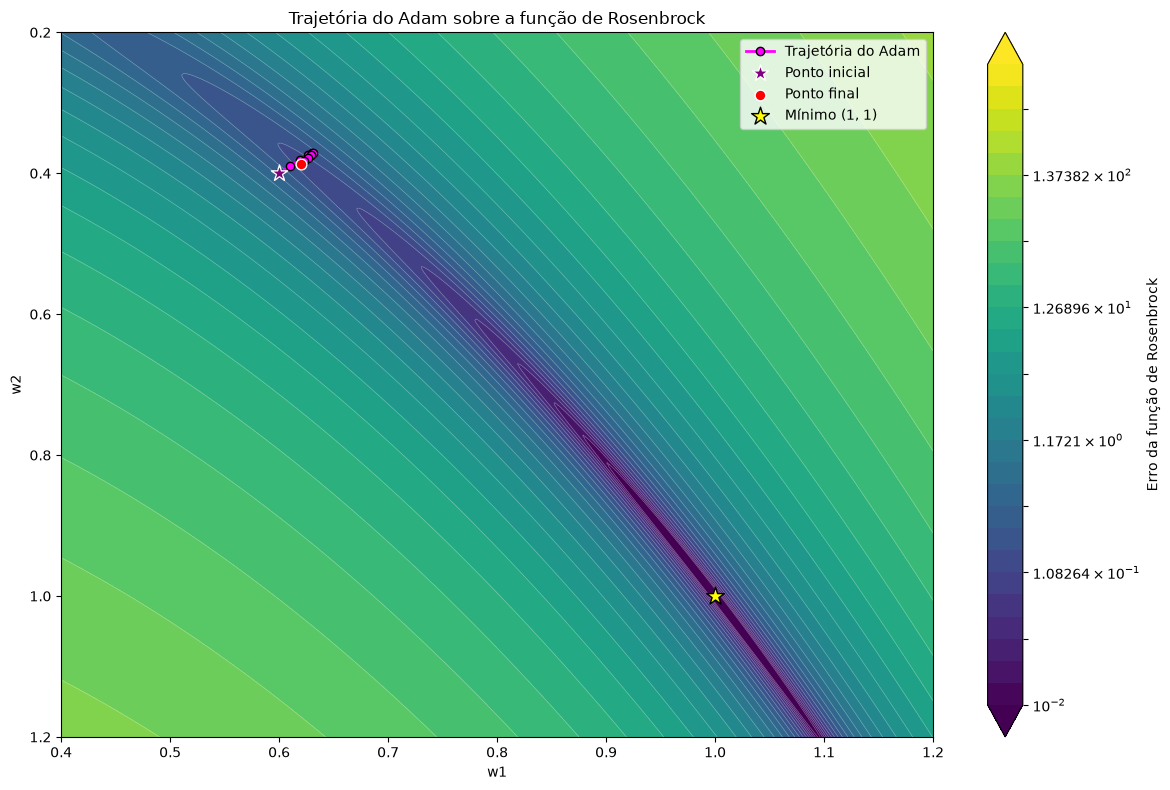

In [59]:
plot_rosenbrock_trajectory(
    adam_result["trajectory"], "Adam", color="magenta"
)
plt.show()

### Análise do Adam

O Adam reduz o erro de `0,320000` para `0,145661` nas duas primeiras atualizações, mas depois apresenta uma pequena oscilação antes de terminar em `0,145565`. O segundo momento diminui o passo nas componentes com gradientes historicamente grandes, enquanto o primeiro momento preserva uma direção média.

O comportamento é mais controlado que o do Momentum, embora não seja monotônico neste horizonte curto. A correção de viés é especialmente relevante nos primeiros passos, pois evita que os momentos inicialmente nulos produzam atualizações artificialmente pequenas.

## Comparação das trajetórias

Os três painéis usam exatamente os mesmos limites, níveis de erro e escala de cores, permitindo comparar diretamente o comportamento dos otimizadores. Deve-se observar tanto a proximidade do ponto final ao vale quanto a regularidade do caminho: trajetórias curtas e suaves tendem a desperdiçar menos atualizações corrigindo oscilações transversais.

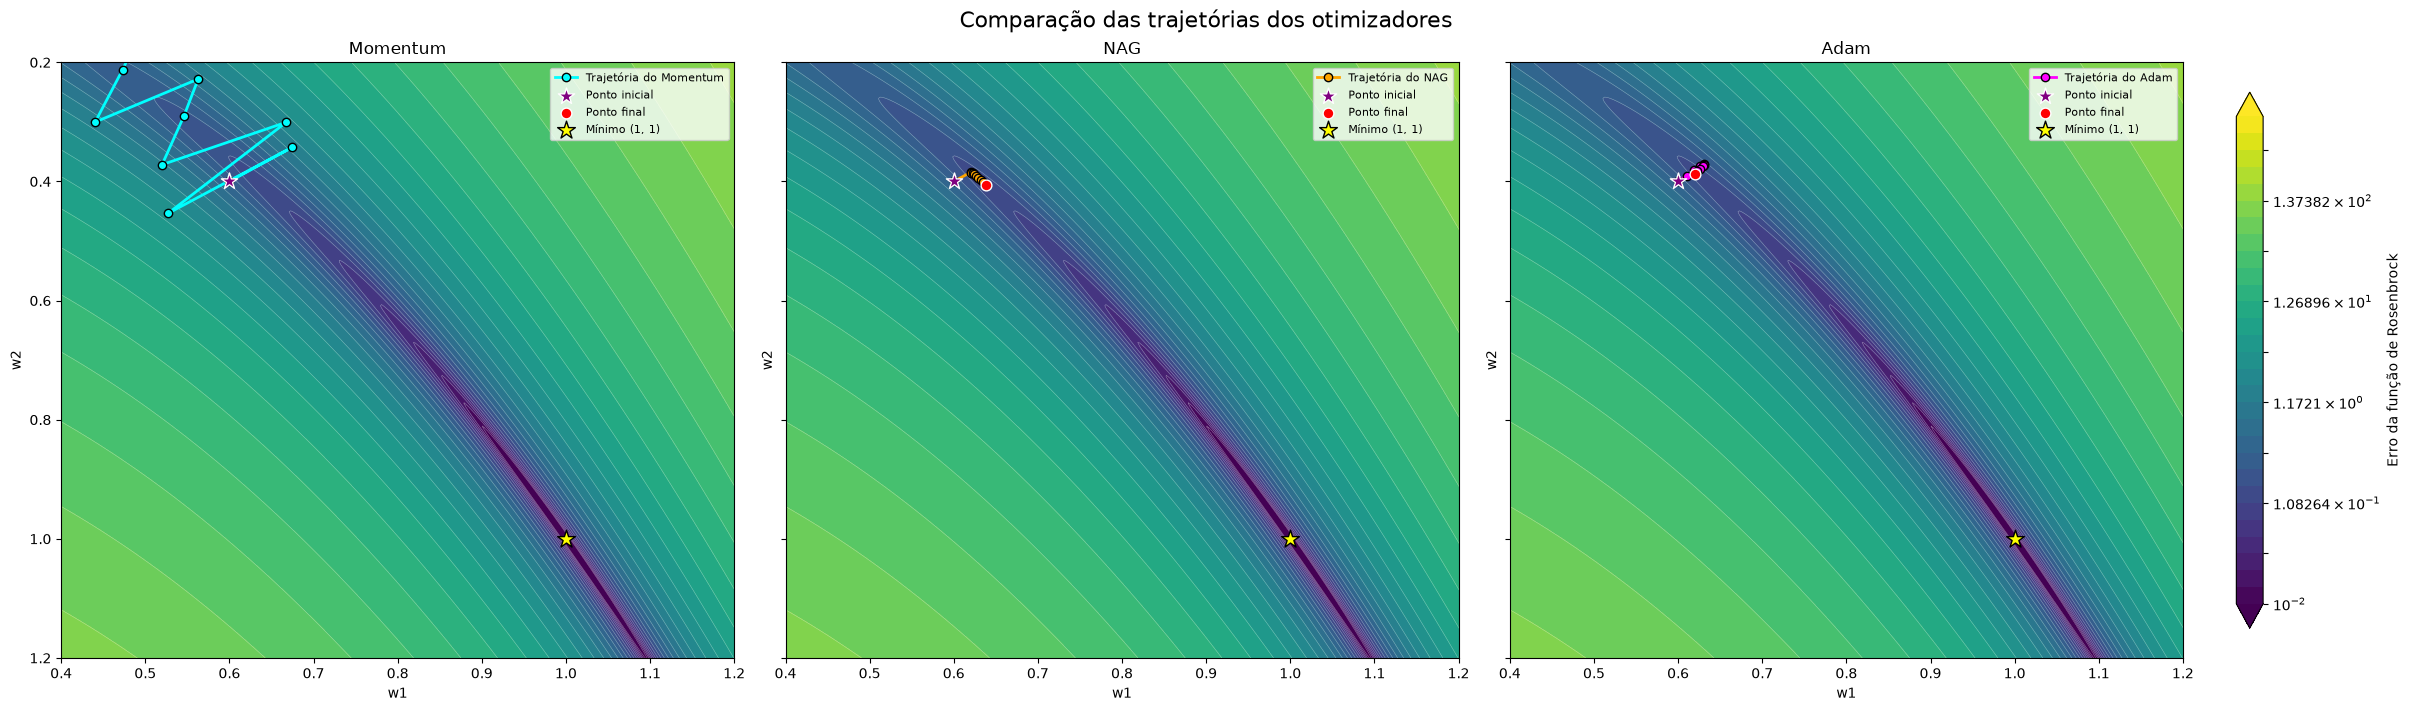

In [60]:
optimizer_results = [
    ("Momentum", momentum_result["trajectory"], "cyan"),
    ("NAG", nag_result["trajectory"], "orange"),
    ("Adam", adam_result["trajectory"], "magenta"),
]

# Uma única superfície e uma única escala são compartilhadas pelos três painéis.
w1_values = np.linspace(0, 2, 1_000)
w2_values = np.linspace(0, 2, 1_000)
W1, W2 = np.meshgrid(w1_values, w2_values)
error_surface = 100.0 * (W2 - W1**2) ** 2 + (1.0 - W1) ** 2
levels = np.logspace(-2, 3, 30)
normalization = LogNorm(vmin=levels[0], vmax=levels[-1])

fig, axes = plt.subplots(
    1, 3, figsize=(24, 7), sharex=True, sharey=True, layout="constrained"
)

for ax, (optimizer_name, trajectory, color) in zip(axes, optimizer_results):
    trajectory_np = trajectory.detach().cpu().numpy()

    background = ax.contourf(
        W1, W2, error_surface, levels=levels, norm=normalization,
        cmap="viridis", extend="both",
    )
    ax.contour(
        W1, W2, error_surface, levels=levels, norm=normalization,
        colors="white", linewidths=0.35, alpha=0.45,
    )
    ax.plot(
        trajectory_np[:, 0], trajectory_np[:, 1], marker="o",
        color=color, markeredgecolor="black", linewidth=2,
        label=f"Trajetória do {optimizer_name}",
    )
    ax.scatter(
        *trajectory_np[0], marker="*", color="purple",
        edgecolor="white", s=150, label="Ponto inicial", zorder=5,
    )
    ax.scatter(
        *trajectory_np[-1], color="red", edgecolor="white",
        s=60, label="Ponto final", zorder=5,
    )
    ax.scatter(
        1.0, 1.0, marker="*", color="yellow", edgecolor="black",
        s=180, label="Mínimo (1, 1)", zorder=6,
    )
    ax.set(
        title=optimizer_name, xlabel="w1", ylabel="w2",
        xlim=(0.4, 1.2), ylim=(0.2, 1.2),
    )
    ax.legend(loc="upper right", fontsize=8)

# Os eixos são compartilhados; basta inverter o eixo vertical uma vez.
axes[0].invert_yaxis()
fig.colorbar(
    background, ax=axes, label="Erro da função de Rosenbrock",
    shrink=0.9, pad=0.02,
)
fig.suptitle("Comparação das trajetórias dos otimizadores", fontsize=16)
plt.show()

## Conclusão

O experimento evidencia como a geometria estreita e curvada da função de Rosenbrock afeta regras de atualização diferentes. Após nove atualizações, os resultados foram:

| Otimizador | Taxa de aprendizado | Ponto final $(w_1,w_2)$ | Erro final | Comportamento observado |
|---|---:|---:|---:|---|
| Momentum | $0{,}007$ | $(0{,}553804, 0{,}244304)$ | $0{,}588399$ | Oscilatório; terminou pior que o ponto inicial |
| NAG | $0{,}002$ | $(0{,}638078, 0{,}405384)$ | $0{,}131297$ | Redução estável e praticamente monotônica |
| Adam | $0{,}01$ | $(0{,}619790, 0{,}387311)$ | $0{,}145565$ | Queda rápida inicial, seguida de pequenas oscilações |

Neste exercício, o **NAG apresentou o menor erro final**, seguido de perto pelo **Adam**. O gradiente antecipado ajudou o NAG a corrigir sua direção antes da atualização, enquanto a normalização adaptativa do Adam controlou componentes com magnitudes de gradiente diferentes. O Momentum, com a configuração adotada, acumulou velocidade demais para o horizonte curto e cruzou repetidamente o vale.

Nenhum método chegou próximo do mínimo global $(1,1)$ em apenas nove atualizações. Além disso, as taxas de aprendizado foram diferentes e escolhidas para manter cada método estável. Assim, os resultados não demonstram superioridade universal de um otimizador; descrevem apenas o comportamento dessas configurações neste ponto inicial.